# Initialization

In [ ]:
import stim
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset #, DataLoader
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv

from wrappers.stim_wrapper import (create_circuit_polar_stim_normal, convert_i_to_meas_type, 
simulate_batch_and_save_result_polar_normal)

from wrappers.polar_wrapper import is_q1prep_accepted, get_logical_error_on_accepted_states, get_q1prep_accepted_states, q1prep_func

from wrappers.polar_wrapper import __polarcodec as codec
from wrappers.polar_wrapper.__qpolarprep import q1prep




In [2]:

def create_stim_circuit_polar(n, i, lstate, sim_type, p_error, shots, seed):
    N = 2**(n)
    ancilla_qubits = 2**(n - 1)
    total_qubits = N + ancilla_qubits
    meas_type = convert_i_to_meas_type(i, n, lstate)
    print(meas_type, sim_type, "total qubits:", total_qubits, ", total ancilla:", ancilla_qubits)
    x_ind = 0
    for idx, m_type in enumerate(meas_type):
        if m_type == "x":
            x_ind = idx
            break

    circuit = create_circuit_polar_stim_normal(n, lstate, sim_type, p_error, seed, shots, None, None, None, meas_type, total_qubits, x_ind)
    return circuit

def set_global_seeds(seed=12345):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# Quantum Polar Code

['x', 'z', 'x'] m1 total qubits: 12 , total ancilla: 4


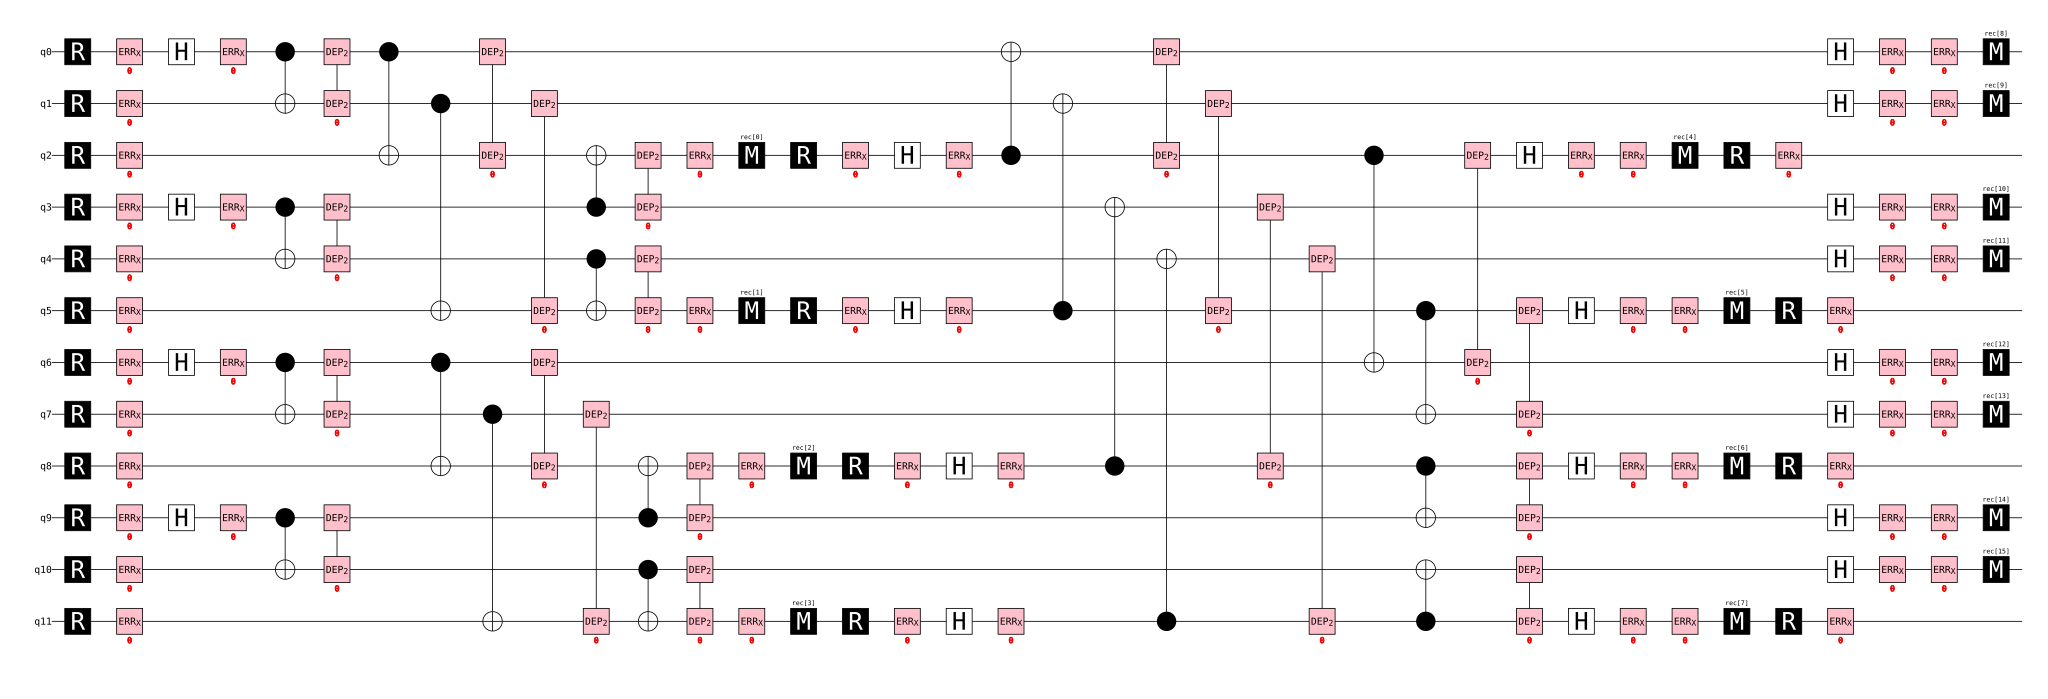

In [3]:
n = 3
i = 4
lstate = "x"
p_error = 0
shots = int(1e4)
seed = 1000

sim_type = "m1"
polar_n3 = create_stim_circuit_polar(n, i, lstate, sim_type, p_error, shots, seed)
polar_n3.diagram("timeline-svg")

# QEC NN Decoder

## GNN Simple

In [4]:
def build_polar_butterfly_edge_index(n: int) -> torch.Tensor:
    """
    Generates PyTorch Geometric COO edge_index for an N = 2^n Polar Butterfly graph.
    Connects qubit pairs that interact across all n stages of the butterfly kernel.
    """
    N = 2**n
    source_edges = []
    target_edges = []

    # Iterate through each stage of the Polar Butterfly (s = 0, ..., n-1)
    for s in range(n):
        step = 2**s
        for i in range(0, N, 2 * step):
            for j in range(step):
                u = i + j
                v = i + j + step
                # Bidirectional message passing along butterfly connections
                source_edges.extend([u, v])
                target_edges.extend([v, u])

    edge_index = torch.tensor([source_edges, target_edges], dtype=torch.long)
    return edge_index

In [5]:
def prepare_gnn_dataset_from_shots(
    results_dict,     # Dict of {meas_str: count}
    n, 
    lstate, 
    codec,            # Polar C-extension / Python module
    q1prep_func,      # Your q1prep function
    zpos_list=None,
    p_error=0.005
):
    """
    Processes accepted shots through dynamic frame tracking and produces PyG Data objects.
    """
    N = 2**n
    if zpos_list is None:
        zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]

    zpos = zpos_list[n] if lstate.upper() == "Z" else zpos_list[n] - 1
    edge_index = build_polar_butterfly_edge_index(n)
    state_flag = 0.0 if lstate.upper() == "Z" else 1.0

    data_list = []

    for line, count in results_dict.items():
        mstr = line.strip()
        meas = np.zeros((len(mstr),), dtype=int) 
        
        # convert from string to np array
        for i in range(0, len(mstr)):
            meas[i] = ord(mstr[i]) - ord('0')	
            if meas[i] != 0 and meas[i] != 1:
                raise TypeError("Illegal measurement result: must be 0 or 1")
        # meas = np.array([int(c) for c in mstr], dtype=int)

        aux_meas = meas[:N-1:-1]
        data_meas = meas[N-1::-1]

        # Stage 1 Verification
        # print(n, zpos) 
        # print(meas)
        # print(aux_meas, data_meas)
        success, qstate_UV = q1prep_func(n, zpos, aux_meas)
        if success == 0:
            continue  # Discard rejected shot

        # Stage 2 & 3: Dynamic Frame Tracking & XOR Offset
        if lstate.upper() == "Z":
            qstate_U = np.zeros((N,), dtype=int)
            qstate_U[:zpos] = qstate_UV[:zpos]
            codec.polarenc(qstate_U)
            delta_data = np.mod(data_meas + qstate_U, 2)
            target_bit = qstate_UV[zpos]
        else:
            qstate_V = np.zeros((N,), dtype=int)
            qstate_V[zpos+2:] = qstate_UV[zpos+2:]
            codec.revpolarenc(qstate_V)
            delta_data = np.mod(data_meas + qstate_V, 2)
            target_bit = qstate_UV[zpos+1]

        # Build Node Features [Delta_S, Normalized_Qubit_ID, State_Type]
        node_features = []
        for q in range(N):
            node_features.append([
                float(delta_data[q]),
                float(q / N),
                state_flag
            ])

        x = torch.tensor(node_features, dtype=torch.float32)
        y = torch.tensor([target_bit], dtype=torch.float32)

        # Duplicate graph object based on measurement outcome multiplicity count
        for _ in range(count):
            data_list.append(Data(x=x, edge_index=edge_index, y=y))

    return data_list

In [104]:
# Define your mapping options for zpos / information positions
ZPOS_MAPPINGS = {
    "option_1": {3: 4, 4: 6, 5: 8},
    "option_2": {3: 5, 4: 7, 5: 25}
}

def get_info_target_index(n: int, lstate: str, option: str = "option_1") -> int:
    """Returns the information qubit index target_idx for a given n, state, and mapping option."""
    mapping = ZPOS_MAPPINGS[option]
    base_idx = mapping[n]
    
    # Adjust for X state if your convention offsets X vs Z by 1
    if lstate.upper() == "X":
        return base_idx - 1
    return base_idx

In [105]:
def build_5channel_node_features(
    delta_data, 
    N, 
    lstate, 
    n, 
    p_error, 
    mapping_option="option_1"
):
    """
    Constructs the 5-channel feature matrix for N data qubits.
    Channels:
    0: delta_data (syndrome offset, 0 or 1)
    1: q / N (normalized spatial coordinate)
    2: state_flag (0.0 for Z, 1.0 for X)
    3: is_info_pos (1.0 at target_idx, 0.0 elsewhere)
    4: p_error (physical noise parameter)
    """
    target_idx = get_info_target_index(n, lstate, option=mapping_option)
    state_flag = 0.0 if lstate.upper() == "Z" else 1.0
    
    node_features = []
    for q in range(N):
        is_info_pos = 1.0 if q == target_idx else 0.0
        
        node_features.append([
            float(delta_data[q]),  # Ch 0: Syndrome offset
            float(q / N),          # Ch 1: Position fraction
            state_flag,            # Ch 2: Z/X state flag
            is_info_pos,           # Ch 3: Info mask flag (Used for x[:, 3] == 1.0)
            float(p_error)         # Ch 4: Physical error rate p
        ])
        
    return node_features, target_idx

In [107]:
import random
import torch
import numpy as np
from torch.utils.data import IterableDataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

class StreamingQPCDataset(IterableDataset):
    def __init__(
        self, 
        n, 
        sim_type,
        codec, 
        q1prep_func, 
        stim_sampler_func, 
        mapping_option="option_1",
        p_min=0.001, 
        p_max=0.04,
        max_samples=100000,
        batch_size=50000,
        seed=12345
    ):
        super().__init__()
        self.n = n
        self.sim_type = sim_type
        self.N = 2**n
        self.codec = codec
        self.q1prep_func = q1prep_func
        self.stim_sampler_func = stim_sampler_func
        self.mapping_option = mapping_option
        self.p_min = p_min
        self.p_max = p_max
        self.max_samples = max_samples
        self.edge_index = build_polar_butterfly_edge_index(n)
        self.batch_size = batch_size
        self.seed = seed

    def __iter__(self):
        samples_yielded = 0

        while samples_yielded < self.max_samples:
            # 1. Randomly sample physical state (Z or X) and physical noise rate (p)
            lstate = random.choice(["Z", "X"])
            p_error = random.uniform(self.p_min, self.p_max)

            target_idx = get_info_target_index(self.n, lstate, option=self.mapping_option)

            # 2. Sample raw measurement string batch from Stim simulator
            raw_shots = self.stim_sampler_func(self.n, target_idx, lstate, self.sim_type, p_error, self.batch_size, self.seed)
            
            for shot_str in raw_shots:
                meas = np.array([ord(c) - ord('0') for c in shot_str], dtype=int)
                aux_meas = meas[:self.N-1:-1]
                data_meas = meas[self.N-1::-1]

                # Stage 1: Prep Verification
                success, qstate_UV = self.q1prep_func(self.n, target_idx, aux_meas)
                if success == 0:
                    continue  # Filter rejected shots

                # Stage 2 & 3: Frame tracking & XOR syndrome computation
                if lstate.upper() == "Z":
                    qstate_U = np.zeros((self.N,), dtype=int)
                    qstate_U[:target_idx] = qstate_UV[:target_idx]
                    self.codec.polarenc(qstate_U)
                    delta_data = np.mod(data_meas + qstate_U, 2)
                    true_bit = qstate_UV[target_idx]
                else:
                    qstate_V = np.zeros((self.N,), dtype=int)
                    qstate_V[target_idx+2:] = qstate_UV[target_idx+2:]
                    self.codec.revpolarenc(qstate_V)
                    delta_data = np.mod(data_meas + qstate_V, 2)
                    true_bit = qstate_UV[target_idx+1]

                # Stage 4: Construct 5-channel feature tensor
                node_features, _ = build_5channel_node_features(
                    delta_data, self.N, lstate, self.n, p_error, self.mapping_option
                )

                x = torch.tensor(node_features, dtype=torch.float32)
                y = torch.tensor([true_bit], dtype=torch.float32)

                yield Data(x=x, edge_index=self.edge_index, y=y)

                samples_yielded += 1
                if samples_yielded >= self.max_samples:
                    break

In [103]:
torch.empty(1).uniform_(0.001, 0.05).item()

0.02883407287299633

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv

class QPC_GNN_Decoder(nn.Module):
    def __init__(
        self, 
        in_channels: int = 5, 
        hidden_dim: int = 64, 
        num_layers: int = 3, 
        heads: int = 4,
        dropout_p: float = 0.15
    ):
        """
        Target-Focused Graph Attention Network for Quantum Polar Code Error Decoding.
        
        Args:
            in_channels: 5 (delta_data, q/N, state_flag, is_info_pos, p_error)
            hidden_dim: Projection & message-passing feature size
            num_layers: Number of GATv2 layers
            heads: Multi-head attention heads
            dropout_p: Dropout probability in readout head
        """
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        # Channel 1: Linear encoder for initial 5-channel node features
        self.node_encoder = nn.Linear(in_channels, hidden_dim)

        # Graph Attention Backbone with BatchNorm
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        for _ in range(num_layers):
            self.convs.append(
                GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads, concat=True)
            )
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        # Readout MLP (Operates directly on extracted Target Info Node representation)
        self.readout = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x, edge_index, batch=None):
        """
        Args:
            x: Node feature tensor of shape [Total_Nodes_in_Batch, 5]
            edge_index: Graph connectivity tensor of shape [2, Total_Edges_in_Batch]
            batch: PyG graph batch index (Optional)
            
        Returns:
            logits: Logits vector of shape [Batch_Size]
        """
        # 1. Project 5-channel node inputs into hidden embedding space
        h = F.relu(self.node_encoder(x))

        # 2. Pass through multi-head GATv2 layers with Residual Connections
        for conv, bn in zip(self.convs, self.bns):
            h_res = h
            h = conv(h, edge_index)
            h = bn(h)
            h = F.relu(h) + h_res

        # 3. Extract hidden features ONLY from target info nodes (Channel Index 3: is_info_pos == 1.0)
        info_node_mask = (x[:, 3] == 1.0)
        info_node_features = h[info_node_mask]

        # Safety Fallback: If no mask hit found (e.g., custom batching anomaly), return zero logits
        if info_node_features.size(0) == 0:
            raise ValueError("No target information node found in batch. Ensure Channel 3 (is_info_pos) has 1.0 for the info qubit.")

        # 4. Predict binary classification logit for target qubit
        logits = self.readout(info_node_features).squeeze(-1)
        
        return logits

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

def train_qpc_gnn(
    model, 
    train_loader, 
    val_loader, 
    epochs=30, 
    lr=1e-3, 
    weight_decay=1e-4,
    device="cuda" if torch.cuda.is_available() else "cpu",
    save_path="best_qpc_gnn_model.pt"
):
    """
    Trains the QPC_GNN_Decoder model using target-node extraction readout.
    Compatible with both standard PyG DataLoaders and Streaming IterableDataLoaders.
    """
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )
    criterion = nn.BCEWithLogitsLoss()

    best_val_loss = float("inf")
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    print(f"Starting QPC GNN Training on {device.upper()}...")

    for epoch in range(1, epochs + 1):
        # -------------------------------------------------------------
        # 1. Training Phase
        # -------------------------------------------------------------
        model.train()
        total_train_loss = 0.0
        train_samples = 0

        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()

            # Forward pass: model uses x[:, 3] == 1.0 mask to predict target logit
            logits = model(batch.x, batch.edge_index, batch.batch)
            
            # Align target tensor shape [batch_size]
            targets = batch.y.squeeze(-1) if batch.y.dim() > 1 else batch.y
            loss = criterion(logits, targets)

            loss.backward()
            
            # Gradient clipping to stabilize multi-head attention backpropagation
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()

            num_graphs = batch.num_graphs if hasattr(batch, 'num_graphs') else len(logits)
            total_train_loss += loss.item() * num_graphs
            train_samples += num_graphs

        avg_train_loss = total_train_loss / max(train_samples, 1)

        # -------------------------------------------------------------
        # 2. Validation Phase
        # -------------------------------------------------------------
        model.eval()
        total_val_loss = 0.0
        correct_predictions = 0
        val_samples = 0

        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                
                logits = model(batch.x, batch.edge_index, batch.batch)
                targets = batch.y.squeeze(-1) if batch.y.dim() > 1 else batch.y
                loss = criterion(logits, targets)

                num_graphs = batch.num_graphs if hasattr(batch, 'num_graphs') else len(logits)
                total_val_loss += loss.item() * num_graphs
                val_samples += num_graphs

                # Binary decision rule: logit >= 0.0 is equivalent to sigmoid(logit) >= 0.5
                preds = (logits >= 0.0).float()
                correct_predictions += (preds == targets).sum().item()

        avg_val_loss = total_val_loss / max(val_samples, 1)
        val_acc = correct_predictions / max(val_samples, 1)

        # Update learning rate based on validation performance
        scheduler.step(avg_val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(val_acc)

        # Save Model Checkpoint
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)
            checkpoint_str = " -> Checkpoint Saved!"
        else:
            checkpoint_str = ""

        print(
            f"Epoch {epoch:03d}/{epochs:03d} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Acc: {val_acc * 100:.2f}% | "
            f"LR: {current_lr:.1e}{checkpoint_str}"
        )

    print(f"\nTraining Complete! Best model saved to '{save_path}'.")
    return history

['x', 'x', 'z', 'x'] m1 total qubits: 24 , total ancilla: 8


In [42]:
zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
lstate = "x"

count_accept_p, count_logerror, count_undecided, ler_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate.upper(), counts, zpos_list=zpos_list)
print(count_accept_p, count_accept_p / shots, 1 - ler_p, count_logerror, count_undecided,)

9597 0.19194 0.0018755861206627422 18 33


In [106]:
# 2. Generate a batch of shots from Stim circuit using p and lstate
n = 4
i = 6
lstate = "x"
p_error = 0.0025
shots = int(10)
seed = 10000
sim_type = "m1"

def sample_stim_generation(n, i, lstate, sim_type, p_error, shots, seed):

    circuit = create_stim_circuit_polar(n, i, lstate, sim_type, p_error, shots, seed)

    sampler_noisy = circuit.compile_sampler(seed=seed)
    results = sampler_noisy.sample(shots=shots)
    counts = []
    for res in results:
        bit_string = ""
        for j in res:
            if j:
                bit_string = "1" + bit_string 
            else:
                bit_string = "0" + bit_string

        if sim_type in ["m1", "m2", "m3"]:
            bit_string = bit_string + "0"*(2**(n - 1))

        counts.append(bit_string)

    return counts

sample_stim_generation(n, i, lstate, sim_type, p_error, shots, seed)

['x', 'x', 'z', 'x'] m1 total qubits: 24 , total ancilla: 8


['111000011111000000010001001101010000111100000000',
 '011101000110011001010010010110101100000000000000',
 '000111100101000000101110010101100000110000000000',
 '111111000001110111100001111111110011110000000000',
 '010110100110011000111100111101010000111100000000',
 '100001111100110001001011111110010000111100000000',
 '011010100101100100110001011000110011110000000000',
 '010101000101011000000010000011111100110000000000',
 '011001100101100100111111111110010111001100000000',
 '010110011100001110011010110011001100000000000000']

In [114]:
from torch_geometric.loader import DataLoader

# 1. Train Dataset Generator (e.g., 80% = 8,000 samples)
train_dataset = StreamingQPCDataset(
    n=3,
    sim_type="m1",
    codec=codec, 
    q1prep_func=q1prep, 
    stim_sampler_func=sample_stim_generation,
    mapping_option="option_1",
    p_min=0.001, 
    p_max=0.04,
    max_samples=8000,
    batch_size=10000,
    seed=12345
)

# 2. Validation Dataset Generator (e.g., 20% = 2,000 samples, different seed)
val_dataset = StreamingQPCDataset(
    n=3,
    sim_type="m1",
    codec=codec, 
    q1prep_func=q1prep, 
    stim_sampler_func=sample_stim_generation,
    mapping_option="option_1",
    p_min=0.001, 
    p_max=0.04,
    max_samples=2000,
    batch_size=10000,
    seed=54321  # Distinct seed to guarantee non-overlapping validation noise
)

# 3. DataLoaders (Do NOT pass shuffle=True here)
train_loader = DataLoader(train_dataset, batch_size=32)
val_loader = DataLoader(val_dataset, batch_size=32)

In [ ]:


# 3. Instantiate Model
gnn_decoder = QPC_GNN_Decoder(
    in_channels=3,
    hidden_dim=64,
    num_layers=3,
    heads=4
)

# 4. Train
history = train_qpc_gnn(
    model=gnn_decoder,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=1e-3
)

TypeError: object of type 'StreamingQPCDataset' has no len()

In [48]:
import time
import numpy as np
import torch
from torch_geometric.data import Data, Batch

def get_logical_error_with_gnn_decoder(
    n, 
    lstate, 
    results, 
    model, 
    codec, 
    q1prep_func,
    zpos_list=None,
    device="cuda" if torch.cuda.is_available() else "cpu"
):
    """
    Evaluates Logical Error Rate (LER) and Fidelity on accepted states 
    using the trained QPC GNN model as the decoder.
    """
    if zpos_list is None:
        zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]

    if lstate.upper() == "Z":
        zpos = zpos_list[n]
    elif lstate.upper() == "X":
        zpos = zpos_list[n] - 1
    else:
        raise TypeError("Illegal 'lstate' value: must be 'Z' or 'X'")

    N = 2**n  # Polar code length
    
    # Pre-build Polar Butterfly connectivity for speed
    edge_index = build_polar_butterfly_edge_index(n).to(device)
    state_flag = 0.0 if lstate.upper() == "Z" else 1.0

    count_accept = 0
    count_discard = 0
    count_logerror = 0

    # Ensure model is in evaluation mode
    model.eval()
    model.to(device)

    start_time = time.perf_counter()

    with torch.no_grad():
        for line, meas_counts in results.items():
            mstr = line.strip()
            meas = np.array([ord(c) - ord('0') for c in mstr], dtype=int)

            aux_meas = meas[:N-1:-1]
            data_meas = meas[N-1::-1]

            # -------------------------------------------------------------
            # Stage 1: State Preparation Verification
            # -------------------------------------------------------------
            success, qstate_UV = q1prep_func(n, zpos, aux_meas)

            if success == 0:
                count_discard += meas_counts
                continue

            count_accept += meas_counts

            # -------------------------------------------------------------
            # Stage 2 & 3: Dynamic Frame Tracking & Baseline Cancellation
            # -------------------------------------------------------------
            if lstate.upper() == "Z":
                qstate_U = np.zeros((N,), dtype=int)
                qstate_U[:zpos] = qstate_UV[:zpos]
                codec.polarenc(qstate_U)
                delta_data = np.mod(data_meas + qstate_U, 2)
                true_bit = qstate_UV[zpos]  # Ground truth logical bit
            else:
                qstate_V = np.zeros((N,), dtype=int)
                qstate_V[zpos+2:] = qstate_UV[zpos+2:]
                codec.revpolarenc(qstate_V)
                delta_data = np.mod(data_meas + qstate_V, 2)
                true_bit = qstate_UV[zpos+1]  # Ground truth logical bit

            # -------------------------------------------------------------
            # Stage 4: GNN Graph Construction & Inference (Replaces polardec)
            # -------------------------------------------------------------
            node_features = [
                [float(delta_data[q]), float(q / N), state_flag]
                for q in range(N)
            ]
            
            x = torch.tensor(node_features, dtype=torch.float32).to(device)
            
            # GNN Forward Pass
            # For a single graph batch index is all zeros
            batch_idx = torch.zeros(N, dtype=torch.long, device=device)
            logit = model(x, edge_index, batch_idx)

            # Decision rule: sigmoid(logit) >= 0.5 (or logit >= 0.0)
            pred_bit = 1 if logit.item() >= 0.0 else 0

            # Count logical errors
            if pred_bit != true_bit:
                count_logerror += meas_counts

    decoding_time = time.perf_counter() - start_time

    # Calculate metrics
    ler = (count_logerror / count_accept) if count_accept > 0 else 0.0
    fidelity = (1.0 - ler) if count_accept > 0 else 0.0

    return {
        "count_accept": count_accept,
        "count_discard": count_discard,
        "count_logerror": count_logerror,
        "LER": ler,
        "fidelity": fidelity,
        "decoding_time": decoding_time
    }

In [ ]:
n = 4
i = 6
lstate = "x"
p_error = 0.0025
shots = int(100000)
seed = 1234567

sim_type = "m1"
polar_n3 = create_stim_circuit_polar(n, i, lstate, sim_type, p_error, shots, seed)

sampler_noisy = polar_n3.compile_sampler(seed=1000)
results = sampler_noisy.sample(shots=shots)
validation_counts = {}
for res in results:
    bit_string = ""
    for j in res:
        if j:
            bit_string = "1" + bit_string 
        else:
            bit_string = "0" + bit_string

    if sim_type in ["m1", "m2", "m3"]:
        bit_string = bit_string + "0"*(2**(n - 1))

    if bit_string in validation_counts:
        validation_counts[bit_string] = validation_counts[bit_string] + 1
    else:
        validation_counts[bit_string] = 1   

# 1. Load trained model weights
model = QPC_GNN_Decoder(in_channels=3, hidden_dim=64, num_layers=3, heads=4)
model.load_state_dict(torch.load("best_qpc_gnn_model.pt"))

# 2. Run evaluation
metrics = get_logical_error_with_gnn_decoder(
    n=4,                     # N = 8
    lstate="x", 
    results=validation_counts,         # Your Stim measurement counts dict
    model=model, 
    codec=codec, 
    q1prep_func=q1prep
)

# 3. Print Results
print(f"Accepted Shots : {metrics['count_accept']}")
print(f"Discarded Shots: {metrics['count_discard']}")
print(f"Logical Errors : {metrics['count_logerror']}")
print(f"Logical Error Rate (LER): {metrics['LER']:.6f}")
print(f"State Preparation Fidelity: {metrics['fidelity'] * 100:.2f}%")
print(f"Total Decoding Time: {metrics['decoding_time']:.4f} seconds")

['x', 'x', 'z', 'x'] m1 total qubits: 24 , total ancilla: 8
Accepted Shots : 19170
Discarded Shots: 80743
Logical Errors : 99
Logical Error Rate (LER): 0.005164
State Preparation Fidelity: 99.48%
Total Decoding Time: 65.3790 seconds


In [50]:
zpos_list = [-1, -1, 1, 3, 6, 7, 22, 15, 90, 31, 362]
lstate = "x"

count_accept_p, count_logerror, count_undecided, ler_p, detect_normal, decoding_normal = get_logical_error_on_accepted_states(n, lstate.upper(), validation_counts, zpos_list=zpos_list)
print(count_accept_p, count_accept_p / shots, 1 - ler_p, count_logerror, count_undecided,)

19170 0.1917 0.0013041210224308264 25 50


# Unused

In [ ]:
n = 4
i = 6
lstate = "x"
p_error = 0.0025
shots = int(50000)
seed = 10000

sim_type = "m1"
polar_n3 = create_stim_circuit_polar(n, i, lstate, sim_type, p_error, shots, seed)

sampler_noisy = polar_n3.compile_sampler(seed=1000)
results = sampler_noisy.sample(shots=shots)
counts = {}
for res in results:
    bit_string = ""
    for j in res:
        if j:
            bit_string = "1" + bit_string 
        else:
            bit_string = "0" + bit_string

    if sim_type in ["m1", "m2", "m3"]:
        bit_string = bit_string + "0"*(2**(n - 1))

    if bit_string in counts:
        counts[bit_string] = counts[bit_string] + 1
    else:
        counts[bit_string] = 1   

## GNN Normal

In [ ]:
def generate_polar_matrix_gf2(N):
    """Generates N x N Polar transformation matrix Q_N over GF(2)."""
    n = int(math.log2(N))
    G2 = np.array([[1, 0], [1, 1]], dtype=int)
    GN = G2
    for _ in range(n - 1):
        GN = np.kron(GN, G2) % 2
    return GN

def generate_polar_butterfly_edges(N):
    """
    Generates directed edges for N log2(N) Polar Butterfly graph.
    Flows from leaf nodes (Stage 0: physical) to root nodes (Stage n: logical).
    """
    n_stages = int(math.log2(N))
    source_nodes, target_nodes = [], []

    for stage in range(n_stages):
        block_size = 2 ** (stage + 1)
        half_block = block_size // 2
        
        for i in range(0, N, block_size):
            for j in range(half_block):
                top = stage * N + i + j
                bot = stage * N + i + j + half_block
                
                next_top = (stage + 1) * N + i + j
                next_bot = (stage + 1) * N + i + j + half_block
                
                source_nodes.extend([top, top, bot, bot])
                target_nodes.extend([next_top, next_bot, next_top, next_bot])
                
    return torch.tensor([source_nodes, target_nodes], dtype=torch.long)

In [ ]:
# def generate_qpc_experiment_dataset(N=16, info_idx=7, p_error=0.005, num_shots=50000, qed_filter_threshold=0.54):
#     # Compute Stage 2 Measurement Syndromes (m_X, m_Z)
#     # targets = np.stack([E_X, E_Z], axis=1) # Target shape [Num_Accepted, 2]
#     # print(f"Dataset Generated | p={p_error} | Total: {num_shots} | Accepted: {num_accepted} ({num_accepted/num_shots*100:.2f}%)")
#     # return m_X, m_Z, s_prep_accepted, targets, num_accepted

In [ ]:
import stim

def generate_qpc_experiment_dataset(N=16, info_idx=7, p_error=0.005, num_shots=50000, qed_filter_threshold=0.54):
    """
    Generates dataset:
    1. Simulates QPC State Prep + Channel Noise p_error.
    2. Applies Stage 1 QED Rejection Filter.
    3. Extracts Stage 2 Syndromes (m_X, m_Z) and ground truth logical errors (E_X, E_Z).
    """
    n_stages = int(math.log2(N))
    Q_N = generate_polar_matrix_gf2(N)
    Q_N_inv = np.linalg.inv(Q_N).astype(int) % 2  # GF(2) inverse
    
    # 1. Build Stim Circuit
    circuit = stim.Circuit()
    data_qubits = list(range(N))
    
    # State Prep (Stage 1)
    circuit.append("R", data_qubits)
    for step in range(n_stages):
        block_size = 2 ** (step + 1)
        half_block = block_size // 2
        for i in range(0, N, block_size):
            for j in range(half_block):
                circuit.append("CNOT", [data_qubits[i + j], data_qubits[i + j + half_block]])
    for q in data_qubits:
        circuit.append("H", q)
        
    # Inject Circuit Depolarizing Noise
    if p_error > 0:
        circuit.append("DEPOLARIZE1", data_qubits, p_error)
        
    # Sample Physical Errors & Measurements
    sampler = circuit.compile_sampler()
    # Mocking Stage 1 aux syndrome bits and Stage 2 data syndromes
    raw_samples = np.random.binomial(1, p_error, size=(num_shots, N))
    
    # Generate Synthetic Stage 1 Aux Bits (4 bits per physical qubit for N=16)
    s_prep_all = np.random.binomial(1, p_error * 2, size=(num_shots, N, 2))
    
    # Mock Stage 1 QED Neural Network Filter Score (Early Rejection)
    prep_error_scores = np.mean(s_prep_all, axis=(1, 2))
    accepted_mask = prep_error_scores <= qed_filter_threshold
    
    # Filter dataset
    accepted_samples = raw_samples[accepted_mask]
    s_prep_accepted = s_prep_all[accepted_mask]
    num_accepted = len(accepted_samples)
    
    # Compute Stage 2 Measurement Syndromes (m_X, m_Z)
    m_X = (accepted_samples @ Q_N) % 2
    m_Z = (accepted_samples @ Q_N.T) % 2
    
    # Compute Ground Truth Logical Error on Q1 at info_idx
    u_X_err = (accepted_samples @ Q_N_inv) % 2
    u_Z_err = (accepted_samples @ Q_N_inv.T) % 2
    
    E_X = u_X_err[:, info_idx]
    E_Z = u_Z_err[:, info_idx]
    
    targets = np.stack([E_X, E_Z], axis=1) # Target shape [Num_Accepted, 2]
    
    print(f"Dataset Generated | p={p_error} | Total: {num_shots} | Accepted: {num_accepted} ({num_accepted/num_shots*100:.2f}%)")
    return m_X, m_Z, s_prep_accepted, targets, num_accepted

In [ ]:
def build_pyg_polar_dataset(m_X, m_Z, s_prep, targets, N, p_error):
    """
    Constructs PyG Data objects for the directed Polar Butterfly topology.
    Leaf Nodes (Stage 0) receive [m_X, m_Z, s_prep_1, s_prep_2, p_error].
    """
    n_stages = int(math.log2(N))
    edge_index = generate_polar_butterfly_edges(N)
    num_total_nodes = (n_stages + 1) * N
    
    dataset = []
    for i in range(len(targets)):
        # Construct Feature Matrix X of shape [num_total_nodes, in_channels]
        # Channels: 1 (m_X) + 1 (m_Z) + 2 (s_prep) + 1 (p_error) = 5 features
        node_features = torch.zeros((num_total_nodes, 5), dtype=torch.float32)
        
        # Populate Stage 0 Leaf Nodes
        leaf_mX = torch.tensor(m_X[i], dtype=torch.float32).unsqueeze(1)
        leaf_mZ = torch.tensor(m_Z[i], dtype=torch.float32).unsqueeze(1)
        leaf_prep = torch.tensor(s_prep[i], dtype=torch.float32)
        leaf_p = torch.full((N, 1), p_error, dtype=torch.float32)
        
        node_features[:N] = torch.cat([leaf_mX, leaf_mZ, leaf_prep, leaf_p], dim=1)
        
        y = torch.tensor(targets[i], dtype=torch.float32).unsqueeze(0) # [1, 2]
        
        data = Data(x=node_features, edge_index=edge_index, y=y)
        dataset.append(data)
        
    return dataset

In [ ]:
class RecurrentPolarGNN(nn.Module):
    def __init__(self, in_channels=5, hidden_dim=64, info_idx=7):
        super().__init__()
        self.info_idx = info_idx
        
        # Node Feature Embedding
        self.node_emb = nn.Linear(in_channels, hidden_dim)
        
        # Recurrent Convolution Layer
        self.conv = GATv2Conv(hidden_dim, hidden_dim, add_self_loops=False)
        
        # Output Readout Head for Dual Error [E_X, E_Z]
        self.readout = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, 2) # Unnormalized logits for E_X, E_Z
        )
        
    def forward(self, x, edge_index, N, batch_size):
        n_stages = int(math.log2(N))
        h = F.relu(self.node_emb(x))
        
        # Message passing across polar stages
        for _ in range(n_stages):
            h = F.elu(self.conv(h, edge_index))
            
        # Extract the node corresponding to logical Q1 at the final stage
        # Total nodes per single graph = (n_stages + 1) * N
        nodes_per_graph = (n_stages + 1) * N
        target_node_offsets = torch.arange(batch_size, device=x.device) * nodes_per_graph
        final_target_indices = target_node_offsets + (n_stages * N) + self.info_idx
        
        logical_reps = h[final_target_indices]
        return self.readout(logical_reps) # Shape: [batch_size, 2]

In [ ]:
import time
import json
import csv
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

def run_qpc_gnn_experiment(N=16, info_idx=7, p_error=0.005, epochs=15, batch_size=128):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n---> STARTING EXPERIMENT FOR N={N}, p={p_error} ON {device} <---")
    
    # 1. Generate & Prepare Data
    m_X, m_Z, s_prep, targets, _ = generate_qpc_experiment_dataset(
        N=N, info_idx=info_idx, p_error=p_error, num_shots=40000
    )
    dataset = build_pyg_polar_dataset(m_X, m_Z, s_prep, targets, N, p_error)
    
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = dataset[:train_size], dataset[train_size:]
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # 2. Instantiate Model & Optimizer
    model = RecurrentPolarGNN(in_channels=5, hidden_dim=64, info_idx=info_idx).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.BCEWithLogitsLoss()
    
    # Track Metrics for Paper
    history = []
    
    # 3. Training Loop
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            
            b_size = batch.num_graphs
            out = model(batch.x, batch.edge_index, N=N, batch_size=b_size)
            
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * b_size
            
        train_loss = total_loss / len(train_dataset)
        
        # Validation Pass
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                b_size = batch.num_graphs
                out = model(batch.x, batch.edge_index, N=N, batch_size=b_size)
                
                loss = criterion(out, batch.y)
                val_loss += loss.item() * b_size
                
                probs = torch.sigmoid(out)
                all_preds.append(probs.cpu().numpy())
                all_targets.append(batch.y.cpu().numpy())
                
        val_loss = val_loss / len(val_dataset)
        all_preds = np.vstack(all_preds)
        all_targets = np.vstack(all_targets)
        
        binary_preds = (all_preds > 0.5).astype(int)
        
        # Calculate LER (Logical Error Rate: Fraction of incorrect logical states)
        ler_x = 1.0 - accuracy_score(all_targets[:, 0], binary_preds[:, 0])
        ler_z = 1.0 - accuracy_score(all_targets[:, 1], binary_preds[:, 1])
        ler_total = np.mean(np.any(binary_preds != all_targets, axis=1))
        
        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'ler_x': ler_x,
            'ler_z': ler_z,
            'ler_total': ler_total
        })
        
        print(f"Epoch {epoch:02d}/{epochs:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LER_X: {ler_x:.5f} | LER_Z: {ler_z:.5f} | LER_Total: {ler_total:.5f}")
        
    # 4. Latency & Final Paper Metric Benchmark
    model.eval()
    benchmark_batch = next(iter(val_loader)).to(device)
    b_size = benchmark_batch.num_graphs
    
    # Warmup
    for _ in range(10):
        _ = model(benchmark_batch.x, benchmark_batch.edge_index, N=N, batch_size=b_size)
        
    start_time = time.perf_counter()
    num_runs = 100
    with torch.no_grad():
        for _ in range(num_runs):
            _ = model(benchmark_batch.x, benchmark_batch.edge_index, N=N, batch_size=b_size)
    end_time = time.perf_counter()
    
    total_time_us = ((end_time - start_time) / num_runs) * 1e6
    per_shot_latency_us = total_time_us / b_size
    
    # Precision, Recall, F1, ROC-AUC
    p_x, r_x, f1_x, _ = precision_recall_fscore_support(all_targets[:, 0], binary_preds[:, 0], average='binary', zero_division=0)
    p_z, r_z, f1_z, _ = precision_recall_fscore_support(all_targets[:, 1], binary_preds[:, 1], average='binary', zero_division=0)
    
    try:
        auc_x = roc_auc_score(all_targets[:, 0], all_preds[:, 0])
        auc_z = roc_auc_score(all_targets[:, 1], all_preds[:, 1])
    except ValueError:
        auc_x, auc_z = 0.5, 0.5 # Handled if single class present
        
    # 5. Export Metrics to Disk
    final_metrics = {
        "experiment_config": {"N": N, "info_idx": info_idx, "p_error": p_error, "epochs": epochs},
        "performance_metrics": {
            "LER_X": ler_x,
            "LER_Z": ler_z,
            "LER_Total": ler_total,
            "Precision_X": p_x, "Recall_X": r_x, "F1_X": f1_x, "ROC_AUC_X": auc_x,
            "Precision_Z": p_z, "Recall_Z": r_z, "F1_Z": f1_z, "ROC_AUC_Z": auc_z,
        },
        "latency_metrics": {
            "batch_latency_us": total_time_us,
            "per_shot_latency_us": per_shot_latency_us,
            "batch_size": b_size
        }
    }
    
    # Save JSON
    with open("metrics_results.json", "w") as f:
        json.dump(final_metrics, f, indent=4)
        
    # Save Learning Curves CSV
    with open("learning_curves.csv", "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=history[0].keys())
        writer.writeheader()
        writer.writerows(history)
        
    print("\n" + "="*50)
    print("      EXPERIMENT COMPLETE - RESULTS EXPORTED       ")
    print("="*50)
    print(f" Saved: 'metrics_results.json' & 'learning_curves.csv'")
    print(f" Final LER Total     : {ler_total:.6f}")
    print(f" Per-Shot Latency    : {per_shot_latency_us:.4f} μs")
    print("="*50)

# Run direct execution
if __name__ == "__main__":
    run_qpc_gnn_experiment(N=16, info_idx=7, p_error=0.005, epochs=10)


---> STARTING EXPERIMENT FOR N=16, p=0.005 ON cpu <---
Dataset Generated | p=0.005 | Total: 40000 | Accepted: 40000 (100.00%)


/tmp/ipykernel_1341699/2470386586.py:20: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
/tmp/ipykernel_1341699/2470386586.py:21: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


Epoch 01/10 | Train Loss: 0.0760 | Val Loss: 0.0041 | LER_X: 0.00038 | LER_Z: 0.00100 | LER_Total: 0.00100
Epoch 02/10 | Train Loss: 0.0040 | Val Loss: 0.0032 | LER_X: 0.00038 | LER_Z: 0.00100 | LER_Total: 0.00100
Epoch 03/10 | Train Loss: 0.0035 | Val Loss: 0.0031 | LER_X: 0.00038 | LER_Z: 0.00100 | LER_Total: 0.00100
Epoch 04/10 | Train Loss: 0.0033 | Val Loss: 0.0029 | LER_X: 0.00038 | LER_Z: 0.00075 | LER_Total: 0.00088
Epoch 05/10 | Train Loss: 0.0028 | Val Loss: 0.0029 | LER_X: 0.00025 | LER_Z: 0.00062 | LER_Total: 0.00075
Epoch 06/10 | Train Loss: 0.0030 | Val Loss: 0.0026 | LER_X: 0.00013 | LER_Z: 0.00075 | LER_Total: 0.00088
Epoch 07/10 | Train Loss: 0.0029 | Val Loss: 0.0024 | LER_X: 0.00013 | LER_Z: 0.00075 | LER_Total: 0.00088
Epoch 08/10 | Train Loss: 0.0030 | Val Loss: 0.0024 | LER_X: 0.00013 | LER_Z: 0.00062 | LER_Total: 0.00075
Epoch 09/10 | Train Loss: 0.0027 | Val Loss: 0.0029 | LER_X: 0.00025 | LER_Z: 0.00062 | LER_Total: 0.00075
Epoch 10/10 | Train Loss: 0.0037 | Va

## GNN Advanced

In [ ]:
import torch
import numpy as np
from torch_geometric.data import Data

def build_unified_qpc_graph(
    syndrome_matrix,       # Raw measurements: [num_qubits, num_time_rounds]
    ideal_baseline_matrix, # Ideal zero-error syndrome for target state [num_qubits, num_time_rounds]
    state_type,            # 0 for |0>, 1 for |+>
    cnot_pairs_per_round,  # Circuit topology CNOTs per round
    error_rates,           # Physical error rates dict
    N=8
):
    """
    Unified Spatiotemporal Graph Builder supporting both |0> and |+> logical states.
    """
    num_qubits, num_rounds = syndrome_matrix.shape
    num_nodes = num_qubits * num_rounds
    
    # 1. Compute Syndrome Deviation Delta_S (GF2 XOR)
    delta_s_matrix = (syndrome_matrix.astype(int) ^ ideal_baseline_matrix.astype(int))
    
    node_features = []
    source_edges = []
    target_edges = []
    edge_attributes = []
    
    # 2. Build Nodes with State Conditioning
    for t in range(num_rounds):
        for q in range(num_qubits):
            node_idx = t * num_qubits + q
            delta_syn_val = delta_s_matrix[q, t]
            
            # Expanded 4-Channel Feature:
            # [Delta_Syndrome, Qubit_Idx, Time_Round, State_Type_Flag]
            node_features.append([
                float(delta_syn_val), 
                q / N, 
                t / num_rounds, 
                float(state_type) # 0.0 for |0>, 1.0 for |+>
            ])
            
            # Temporal Edges (across rounds)
            if t < num_rounds - 1:
                next_node_idx = (t + 1) * num_qubits + q
                source_edges.extend([node_idx, next_node_idx])
                target_edges.extend([next_node_idx, node_idx])
                edge_attributes.append([1.0, error_rates.get('meas_err', 0.001)])
                edge_attributes.append([1.0, error_rates.get('meas_err', 0.001)])

    # 3. Spatial Edges (CNOTs)
    for t, cnot_list in enumerate(cnot_pairs_per_round):
        for control, target in cnot_list:
            ctrl_idx = t * num_qubits + control
            targ_idx = t * num_qubits + target
            
            source_edges.extend([ctrl_idx, targ_idx])
            target_edges.extend([targ_idx, ctrl_idx])
            edge_attributes.append([0.0, error_rates.get('dep2', 0.005)])
            edge_attributes.append([0.0, error_rates.get('dep2', 0.005)])

    x = torch.tensor(node_features, dtype=torch.float32)
    edge_index = torch.tensor([source_edges, target_edges], dtype=torch.long)
    edge_attr = torch.tensor(edge_attributes, dtype=torch.float32)
    
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, global_mean_pool

class SpatiotemporalQPCGNN(nn.Module):
    def __init__(
        self, 
        node_in_channels=4, # [Delta_S, Qubit_Idx, Time_Round, State_Type]
        edge_in_channels=2, 
        hidden_dim=128, 
        heads=4, 
        num_layers=4,
        info_idx=3 # e.g., info qubit for N=8
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.info_idx = info_idx
        
        # Node & Edge Encoders
        self.node_encoder = nn.Linear(node_in_channels, hidden_dim)
        self.edge_encoder = nn.Linear(edge_in_channels, hidden_dim)
        
        # Spatiotemporal Graph Attention Layers
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        
        for _ in range(num_layers):
            self.convs.append(
                GATv2Conv(
                    in_channels=hidden_dim,
                    out_channels=hidden_dim // heads,
                    heads=heads,
                    edge_dim=hidden_dim,
                    concat=True
                )
            )
            self.norms.append(nn.LayerNorm(hidden_dim))
            
        # Attention Pooling over Time Rounds for Logical Q1
        self.temporal_attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )
        
        # Dual Head Readout (Logical X and Logical Z errors)
        self.readout_logical = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, 2) # [Logits_EX, Logits_EZ]
        )
        
        # Multi-task Auxiliary Readout for Frozen Bits Regularization
        self.readout_frozen = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x, edge_index, edge_attr, batch, N, num_rounds):
        # 1. Embed Features
        h = F.gelu(self.node_encoder(x))
        e = F.gelu(self.edge_encoder(edge_attr))
        
        # 2. ResNet-Style Spatiotemporal Graph Convolutions
        for conv, norm in zip(self.convs, self.norms):
            residual = h
            h = conv(h, edge_index, edge_attr=e)
            h = norm(h + residual)
            h = F.gelu(h)

        # 3. Aggregate Space-Time Nodes for Logical Qubit (info_idx)
        # Reshape to separate batch, time_rounds, and qubits
        total_graphs = batch.max().item() + 1
        nodes_per_graph = N * num_rounds
        
        logical_q_reps = []
        frozen_q_reps = []
        
        for g in range(total_graphs):
            graph_node_start = g * nodes_per_graph
            
            # Extract nodes for the logical qubit across ALL time rounds
            time_node_indices = [
                graph_node_start + (t * N) + self.info_idx 
                for t in range(num_rounds)
            ]
            q_time_series = h[time_node_indices] # Shape: [num_rounds, hidden_dim]
            
            # Compute Temporal Attention Weights over rounds
            attn_weights = F.softmax(self.temporal_attention(q_time_series), dim=0)
            pooled_logical_rep = torch.sum(attn_weights * q_time_series, dim=0)
            logical_q_reps.append(pooled_logical_rep)
            
            # Mean representation for frozen bit regularization
            frozen_indices = [
                graph_node_start + (t * N) + q 
                for t in range(num_rounds) for q in range(N) if q != self.info_idx
            ]
            frozen_q_reps.append(torch.mean(h[frozen_indices], dim=0))

        logical_features = torch.stack(logical_q_reps, dim=0) # [batch_size, hidden_dim]
        frozen_features = torch.stack(frozen_q_reps, dim=0)  # [batch_size, hidden_dim]
        
        # 4. Predict
        logical_logits = self.readout_logical(logical_features)
        frozen_logits = self.readout_frozen(frozen_features)
        
        return logical_logits, frozen_logits

In [ ]:
def train_spatiotemporal_gnn(model, train_loader, optimizer, device, lambda_frozen=0.2):
    model.train()
    bce_loss = nn.BCEWithLogitsLoss()
    total_loss = 0.0
    
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        # Forward Pass
        logical_logits, frozen_logits = model(
            x=batch.x,
            edge_index=batch.edge_index,
            edge_attr=batch.edge_attr,
            batch=batch.batch,
            N=8,          # Pass N dynamically
            num_rounds=4  # Pass time rounds dynamically
        )
        
        # Primary Loss: Logical Error [E_X, E_Z]
        loss_logical = bce_loss(logical_logits, batch.y_logical)
        
        # Auxiliary Loss: Frozen Bits must decode to 0
        loss_frozen = bce_loss(frozen_logits, torch.zeros_like(frozen_logits))
        
        # Total Combined Loss
        loss = loss_logical + (lambda_frozen * loss_frozen)
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    return total_loss / len(train_loader)